Codes to Question 1_2

Analyze the kalman filter's optimality and numerical stability


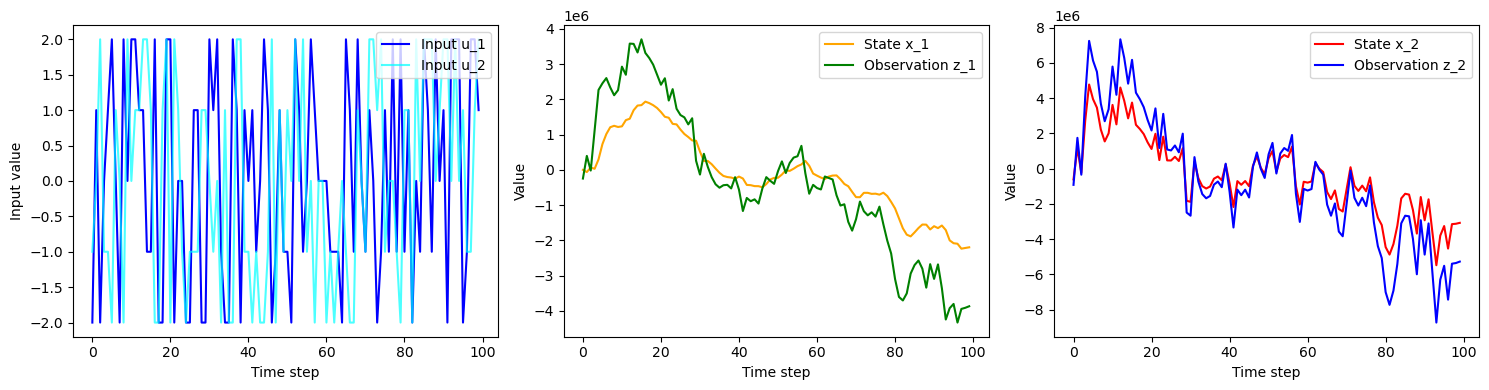

In [1]:
import numpy as np
import matplotlib.pyplot as plt
# random seed
np.random.seed(26)

#  Set sequence length
size = 100
# Dimensions
state_dim = 2
input_dim = 2
obs_dim = 2

# Initial state
x0 = np.array([0.5, -0.3])

uk = np.random.choice(np.arange(-2, 3), size=(size, input_dim)) # Random inputs
xk = np.zeros((size, state_dim)) # hidden states
zk = np.zeros((size, obs_dim)) # observations

# System matrices
A = np.array([[0.85, 0.1],
              [0.05, 0.9]])
B = np.array([[1.5, 0.2],
              [0.1, 1.8]])
C = np.array([[1.2, 0.4],
              [0.3, 1.5]])
D = np.array([[0.5, -0.3],
              [-0.2, 0.7]])

# Covariance matrices for process and measurement noise
Q = np.diag([2.0, 1.5])
R = np.diag([3.0, 2.5])

# Ill-Conditioned
Q = np.diag([1e-12, 1e12])  
R = np.diag([1e-15, 1e5])  


process_noises = []
measurement_noises = []

for i, u in enumerate(uk):
    process_noise = np.random.multivariate_normal(mean=np.zeros(state_dim), cov=Q)
    process_noises.append(process_noise)
    if i == 0:
        xk[i] = A @ x0 + B @ u + process_noise
    else:
        xk[i] = A @ xk[i - 1] + B @ u + process_noise

    measurement_noise = np.random.multivariate_normal(mean=np.zeros(obs_dim), cov=R)
    measurement_noises.append(measurement_noise)
    zk[i] = C @ xk[i] + D @ u + measurement_noise

process_noises = np.vstack(process_noises)       # (size, 2)
measurement_noises = np.vstack(measurement_noises)  # (size, 2)


plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.plot(uk[:, 0], label='Input u_1', color='blue')
plt.plot(uk[:, 1], label='Input u_2', color='cyan', alpha=0.7)
plt.xlabel('Time step')
plt.ylabel('Input value')
plt.legend(loc='upper right')
plt.subplot(1, 3, 2)
plt.plot(xk[:, 0], label='State x_1', color='orange')
plt.plot(zk[:, 0], label='Observation z_1', color='green')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend(loc='upper right')
plt.subplot(1, 3, 3)
plt.plot(xk[:, 1], label='State x_2', color='red')
plt.plot(zk[:, 1], label='Observation z_2', color='blue')
plt.xlabel('Time step')
plt.ylabel('Value')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [2]:
# conditon number calculation via SVD
def svd_and_cond(A: np.ndarray):
    Aw = A.astype(np.float32, copy=False) if A.dtype == np.float16 else A
    S = np.linalg.svd(Aw, compute_uv=False)

    sigma_max = np.max(S)
    sigma_min = np.min(S)
    cond_manual = sigma_max / sigma_min
    return cond_manual

def eigvalsh_safe(SigmaX: np.ndarray):
    compute_dtype = np.float32 if SigmaX.dtype == np.float16 else SigmaX.dtype
    SigmaXw = SigmaX.astype(compute_dtype, copy=False)

    eigvals = np.linalg.eigvalsh(SigmaXw)
    eigvals_out = eigvals
    # eigvals_out = eigvals.astype(np.float16) if SigmaX.dtype == np.float16 else eigvals

    return eigvals_out

def inv_safe(S: np.ndarray):
    compute_dtype = np.float32 if S.dtype == np.float16 else S.dtype
    Sw = S.astype(compute_dtype, copy=False)
    inv_S = np.linalg.inv(Sw)
    inv_S_out = inv_S
    # inv_S_out = inv_S.astype(np.float16) if S.dtype == np.float16 else inv_S
    return inv_S_out

1. filtered means/covariances compared to the true means/covariances

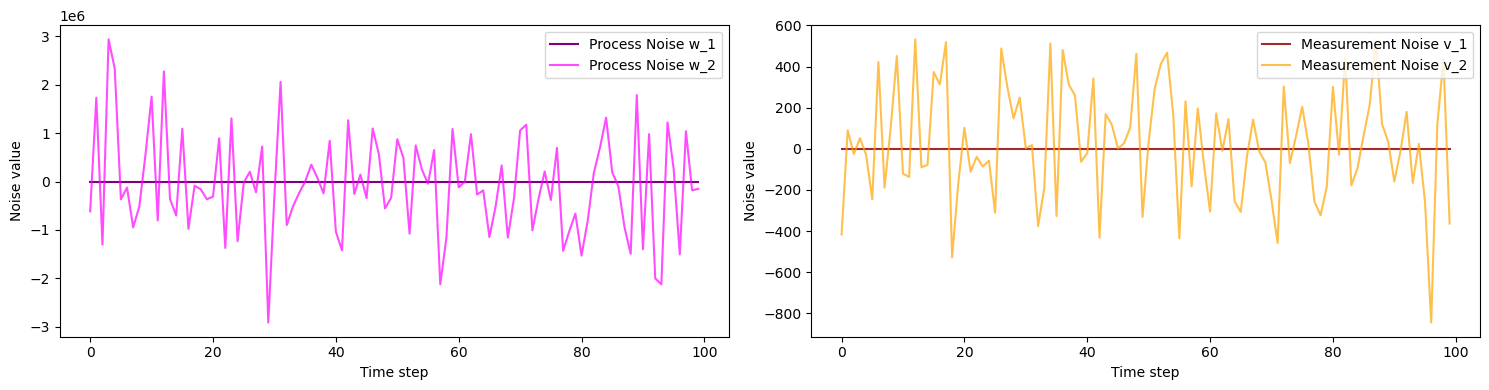

In [3]:
# plot process and measurement noise
plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
plt.plot(process_noises[:, 0], label='Process Noise w_1', color='purple')
plt.plot(process_noises[:, 1], label='Process Noise w_2', color='magenta', alpha=0.7)
plt.xlabel('Time step')
plt.ylabel('Noise value')
plt.legend(loc='upper right')
plt.subplot(1, 2, 2)
plt.plot(measurement_noises[:, 0], label='Measurement Noise v_1', color='brown')
plt.plot(measurement_noises[:, 1], label='Measurement Noise v_2', color='orange', alpha=0.7)
plt.xlabel('Time step')
plt.ylabel('Noise value')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [4]:
# implement the Kalman filter for the multidimensional LG-SSM

# initial model guess
params = {}
params["A"] = np.array([[0.75, 0.05],
                    [0.02, 0.8]])  
params["B"] = np.array([[1.2, 0.1],
                    [0.05, 1.4]])
params["C"] = np.array([[1.0, 0.3],
                    [0.2, 1.2]])
params["D"] = np.array([[0.4, -0.2],
                    [-0.1, 0.5]])

params["Q"] = np.diag([3.5, 2.5])   # sigma W (guess)
params["R"] = np.diag([4.5, 3.5])   # sigma V (guess)

# Ill-Conditione
params["Q"] = np.diag([1e-2, 1e8]) 
params["R"] = np.diag([1e-10, 1e2])


# precision setting
dtype = np.float32  # np.float64 (15～17 digits), np.float32 (6~8 digits)， np.float16 (3~4 digits)
for k in ["A", "B", "C", "D", "Q", "R"]:
    params[k] = params[k].astype(dtype)
uk = uk.astype(dtype)
zk = zk.astype(dtype)


time_idx = np.arange(size)
# initial guesses
xhat = np.zeros(state_dim, dtype=dtype)
SigmaX = np.eye(state_dim, dtype=dtype)
xhatstore = np.zeros((size, state_dim), dtype=dtype)
boundstore = np.zeros((size, state_dim), dtype=dtype)
xhatstore[0] = xhat
boundstore[0] = 3 * np.sqrt(np.diag(SigmaX))

xhatstore_std = np.zeros((size, state_dim), dtype=dtype)
boundstore_std = np.zeros((size, state_dim), dtype=dtype)

# Track covariance properties for standard KF
eigenvalues_std = np.zeros((size, state_dim), dtype=dtype)
min_eigenvalues_std = np.zeros(size, dtype=dtype)
symmetry_error_std = np.zeros(size, dtype=dtype)
condition_number_std = np.zeros(size, dtype=dtype)

xhatstore_std[0] = xhat
boundstore_std[0] = 3 * np.sqrt(np.diag(SigmaX))
eigenvalues_std[0] = eigvalsh_safe(SigmaX)
min_eigenvalues_std[0] = np.min(eigenvalues_std[0])
symmetry_error_std[0] = np.max(np.abs(SigmaX - SigmaX.T))
# condition number?
condition_number_std[0] = svd_and_cond(SigmaX)

# execute Kalman filter
for t in range(1, size):
    # KF Step 1a: State estimate time update (prediction)
    xhat_pred = params["A"] @ xhat + params["B"] @ uk[t - 1]
    # KF Step 1b: Error covariance time update
    SigmaX_pred = params["A"] @ SigmaX @ params["A"].T + params["Q"]
    # KF Step 1c: Estimate system output
    zhat = params["C"] @ xhat_pred + params["D"] @ uk[t]

    # KF Step 2a: Compute Kalman gain
    S = params["C"] @ SigmaX_pred @ params["C"].T + params["R"]
    L = SigmaX_pred @ params["C"].T @ inv_safe(S)
    # KF Step 2b: State estimate measurement update
    xhat = xhat_pred + L @ (zk[t] - zhat)
    # KF Step 2c: Error covariance measurement update
    SigmaX = (np.eye(state_dim) - L @ params["C"]) @ SigmaX_pred

    # Track properties
    eigenvalues_std[t] = eigvalsh_safe(SigmaX)
    min_eigenvalues_std[t] = np.min(eigenvalues_std[t])
    symmetry_error_std[t] = np.linalg.norm(SigmaX - SigmaX.T, ord='fro')
    # condition_number_std[t] = np.linalg.cond(SigmaX, 2)
    condition_number_std[t] = svd_and_cond(SigmaX)

    xhatstore[t] = xhat
    boundstore[t] = 3 * np.sqrt(np.diag(SigmaX))
    # boundstore[t] = 3 * np.sqrt(np.clip(np.diag(SigmaX), a_min=0.0, a_max=None))

# Compute estimated noises from Kalman filter
estimated_process_noise = np.zeros((size, state_dim))
estimated_measurement_noise = np.zeros((size, obs_dim))

for t in range(1, size):
    # Estimated process noise: difference between predicted and actual next state
    if t < size - 1:
        xhat_next_pred = params["A"] @ xhatstore[t] + params["B"] @ uk[t]
        estimated_process_noise[t] = xhatstore[t + 1] - xhat_next_pred
    
    # Estimated measurement noise: innovation (observation residual)
    zhat = params["C"] @ xhatstore[t] + params["D"] @ uk[t]
    estimated_measurement_noise[t] = zk[t] - zhat


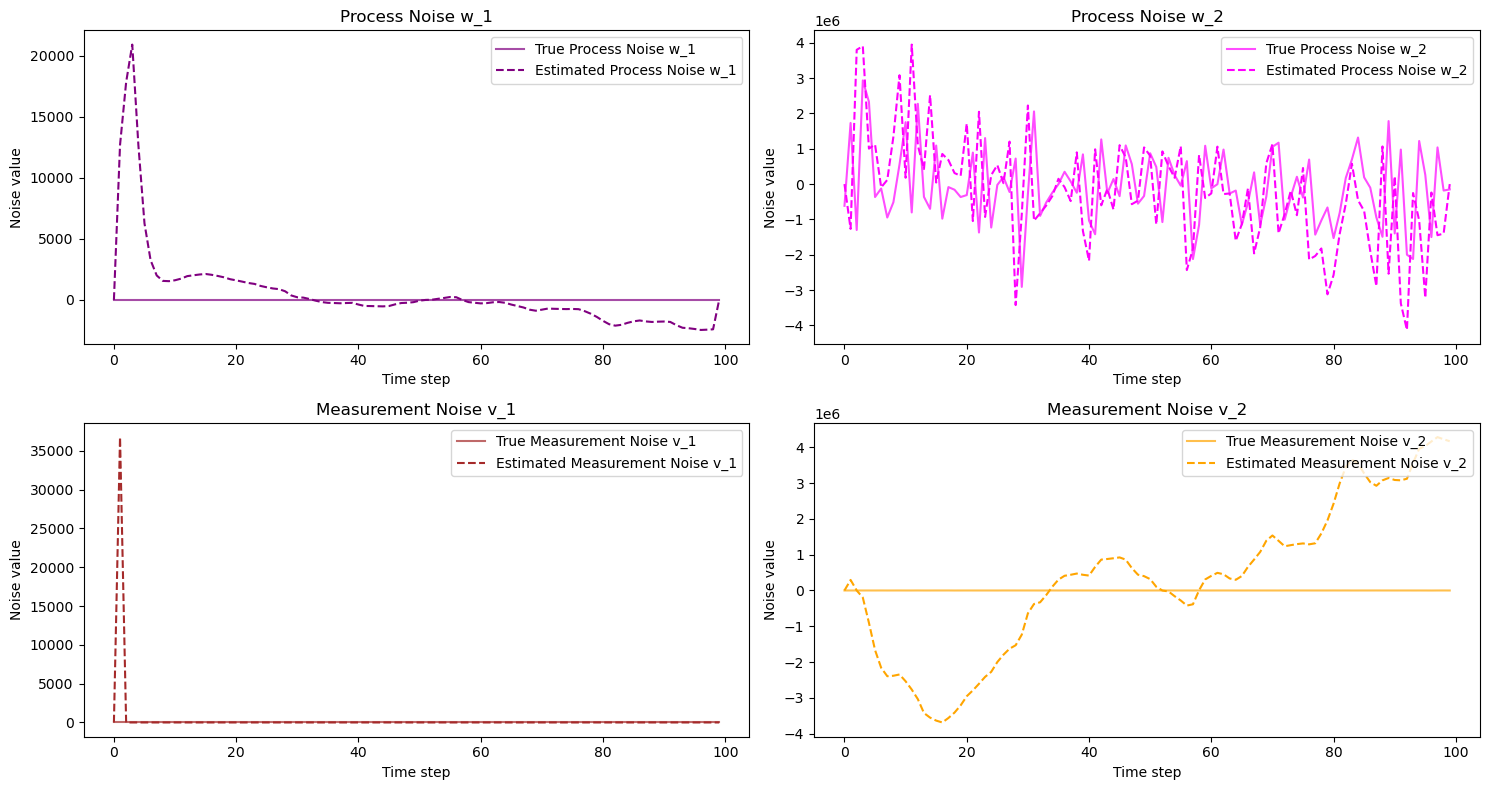

Process Noise w_1: True Mean = 2.1781544017960865e-07 , Estimated Mean = 526.56611328125
Process Noise w_1: True Covariance = 9.001752269352927e-13 , Estimated Covariance = 12649406.60674389
Process Noise w_2: True Mean = -64654.293217477956 , Estimated Mean = -232636.990625
Process Noise w_2: True Covariance = 1115668313667.0032 , Estimated Covariance = 2352955913365.968
Measurement Noise v_1: True Mean = -2.2509226545052827e-10 , Estimated Mean = 367.616953125
Measurement Noise v_1: True Covariance = 9.850362739006127e-16 , Estimated Covariance = 13513822.092657782
Measurement Noise v_2: True Mean = 25.78268725644118 , Estimated Mean = 310866.670625
Measurement Noise v_2: True Covariance = 76612.41137141369 , Estimated Covariance = 4551040739789.965


In [5]:
# Plot comparison of true vs estimated noises
plt.figure(figsize=(15, 8))

# Process noise comparison
plt.subplot(2, 2, 1)
plt.plot(process_noises[:, 0], label='True Process Noise w_1', color='purple', alpha=0.7)
plt.plot(estimated_process_noise[:, 0], label='Estimated Process Noise w_1', color='purple', linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Noise value')
plt.legend(loc='upper right')
plt.title('Process Noise w_1')

plt.subplot(2, 2, 2)
plt.plot(process_noises[:, 1], label='True Process Noise w_2', color='magenta', alpha=0.7)
plt.plot(estimated_process_noise[:, 1], label='Estimated Process Noise w_2', color='magenta', linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Noise value')
plt.legend(loc='upper right')
plt.title('Process Noise w_2')

# Measurement noise comparison
plt.subplot(2, 2, 3)
plt.plot(measurement_noises[:, 0], label='True Measurement Noise v_1', color='brown', alpha=0.7)
plt.plot(estimated_measurement_noise[:, 0], label='Estimated Measurement Noise v_1', color='brown', linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Noise value')
plt.legend(loc='upper right')
plt.title('Measurement Noise v_1')

plt.subplot(2, 2, 4)
plt.plot(measurement_noises[:, 1], label='True Measurement Noise v_2', color='orange', alpha=0.7)
plt.plot(estimated_measurement_noise[:, 1], label='Estimated Measurement Noise v_2', color='orange', linestyle='--')
plt.xlabel('Time step')
plt.ylabel('Noise value')
plt.legend(loc='upper right')
plt.title('Measurement Noise v_2')

plt.tight_layout()
plt.show()

# mean and covariance for each plot
print("Process Noise w_1: True Mean =", np.mean(process_noises[:, 0]), ", Estimated Mean =", np.mean(estimated_process_noise[:, 0]))
print("Process Noise w_1: True Covariance =", np.cov(process_noises[:, 0]), ", Estimated Covariance =", np.cov(estimated_process_noise[:, 0]))
print("Process Noise w_2: True Mean =", np.mean(process_noises[:, 1]), ", Estimated Mean =", np.mean(estimated_process_noise[:, 1]))
print("Process Noise w_2: True Covariance =", np.cov(process_noises[:, 1]), ", Estimated Covariance =", np.cov(estimated_process_noise[:, 1]))
print("Measurement Noise v_1: True Mean =", np.mean(measurement_noises[:, 0]), ", Estimated Mean =", np.mean(estimated_measurement_noise[:, 0]))
print("Measurement Noise v_1: True Covariance =", np.cov(measurement_noises[:, 0]), ", Estimated Covariance =", np.cov(estimated_measurement_noise[:, 0]))
print("Measurement Noise v_2: True Mean =", np.mean(measurement_noises[:, 1]), ", Estimated Mean =", np.mean(estimated_measurement_noise[:, 1]))
print("Measurement Noise v_2: True Covariance =", np.cov(measurement_noises[:, 1]), ", Estimated Covariance =", np.cov(estimated_measurement_noise[:, 1]))  

2. Employ Joseph stabilized covariance update

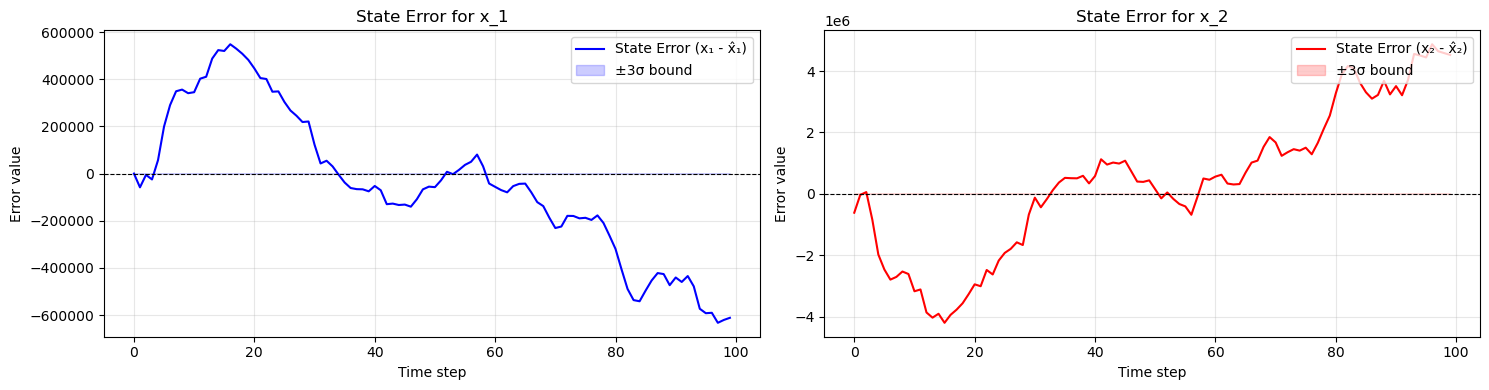

Percentage of x_1 errors within ±3σ bounds: 1.0%
Percentage of x_2 errors within ±3σ bounds: 0.0%


In [6]:
# State error with bounds
xerrKF = xk - xhatstore

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(time_idx, xerrKF[:, 0], label='State Error (x₁ - x̂₁)', color='blue')
axs[0].fill_between(time_idx,
                    -boundstore[:, 0],
                    boundstore[:, 0],
                    color='blue', alpha=0.2, label='±3σ bound')
axs[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Error value')
axs[0].set_title('State Error for x_1')
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

axs[1].plot(time_idx, xerrKF[:, 1], label='State Error (x₂ - x̂₂)', color='red')
axs[1].fill_between(time_idx,
                    -boundstore[:, 1],
                    boundstore[:, 1],
                    color='red', alpha=0.2, label='±3σ bound')
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Error value')
axs[1].set_title('State Error for x_2')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate percentage of errors within bounds
within_bounds_x1 = np.sum(np.abs(xerrKF[:, 0]) <= boundstore[:, 0]) / size * 100
within_bounds_x2 = np.sum(np.abs(xerrKF[:, 1]) <= boundstore[:, 1]) / size * 100
print(f"Percentage of x_1 errors within ±3σ bounds: {within_bounds_x1:.1f}%")
print(f"Percentage of x_2 errors within ±3σ bounds: {within_bounds_x2:.1f}%")

In [7]:
# implement the KF with Joseph stabilized covariance update
time_idx = np.arange(size)
# initial guesses
xhat = np.zeros(state_dim, dtype=dtype)
SigmaX = np.eye(state_dim, dtype=dtype)
# SigmaX = 1e-10*np.eye(state_dim) # SigmaX must be positive definite
xhatstore = np.zeros((size, state_dim), dtype=dtype)
boundstore = np.zeros((size, state_dim), dtype=dtype)
xhatstore[0] = xhat
boundstore[0] = 3 * np.sqrt(np.diag(SigmaX))

xhatstore_joseph = np.zeros((size, state_dim), dtype=dtype)
boundstore_joseph = np.zeros((size, state_dim), dtype=dtype)

# Track covariance properties for Joseph KF
eigenvalues_joseph = np.zeros((size, state_dim), dtype=dtype)
min_eigenvalues_joseph = np.zeros(size, dtype=dtype)
symmetry_error_joseph = np.zeros(size, dtype=dtype)
condition_number_joseph = np.zeros(size, dtype=dtype)

xhatstore_joseph[0] = xhat
boundstore_joseph[0] = 3 * np.sqrt(np.diag(SigmaX))
eigenvalues_joseph[0] = eigvalsh_safe(SigmaX)
min_eigenvalues_joseph[0] = np.min(eigenvalues_joseph[0])
symmetry_error_joseph[0] = np.max(np.abs(SigmaX - SigmaX.T))
# condition number?
condition_number_joseph[0] = svd_and_cond(SigmaX)


# execute Kalman filter
for t in range(1, size):
    # KF Step 1a: State estimate time update (prediction)
    xhat_pred = params["A"] @ xhat + params["B"] @ uk[t - 1]
    # KF Step 1b: Error covariance time update
    SigmaX_pred = params["A"] @ SigmaX @ params["A"].T + params["Q"]
    # KF Step 1c: Estimate system output
    zhat = params["C"] @ xhat_pred + params["D"] @ uk[t]

    # KF Step 2a: Compute Kalman gain
    S = params["C"] @ SigmaX_pred @ params["C"].T + params["R"]
    L = SigmaX_pred @ params["C"].T @ inv_safe(S)
    # KF Step 2b: State estimate measurement update
    xhat = xhat_pred + L @ (zk[t] - zhat)

    # KF Step 2c: Error covariance measurement update
    # SigmaX = (np.eye(state_dim) - L @ params["C"]) @ SigmaX_pred
    # KF Step 2c: Error covariance measurement update (Joseph form)
    I_LC = np.eye(state_dim) - L @ params["C"]
    SigmaX = I_LC @ SigmaX_pred @ I_LC.T + L @ params["R"] @ L.T
    # SigmaX = (SigmaX + SigmaX.T) / 2.0
    # SigmaX = np.maximum(SigmaX, 0.0)

    # Track properties
    eigenvalues_joseph[t] = eigvalsh_safe(SigmaX)
    min_eigenvalues_joseph[t] = np.min(eigenvalues_joseph[t])
    symmetry_error_joseph[t] = np.linalg.norm(SigmaX - SigmaX.T, ord='fro')
    # condition_number_joseph[t] = np.linalg.cond(SigmaX, 2)
    condition_number_joseph[t] = svd_and_cond(SigmaX)

    xhatstore_joseph[t] = xhat
    boundstore_joseph[t] = 3 * np.sqrt(np.diag(SigmaX))
    # boundstore_joseph[t] = 3 * np.sqrt(np.clip(np.diag(SigmaX), a_min=0.0, a_max=None))

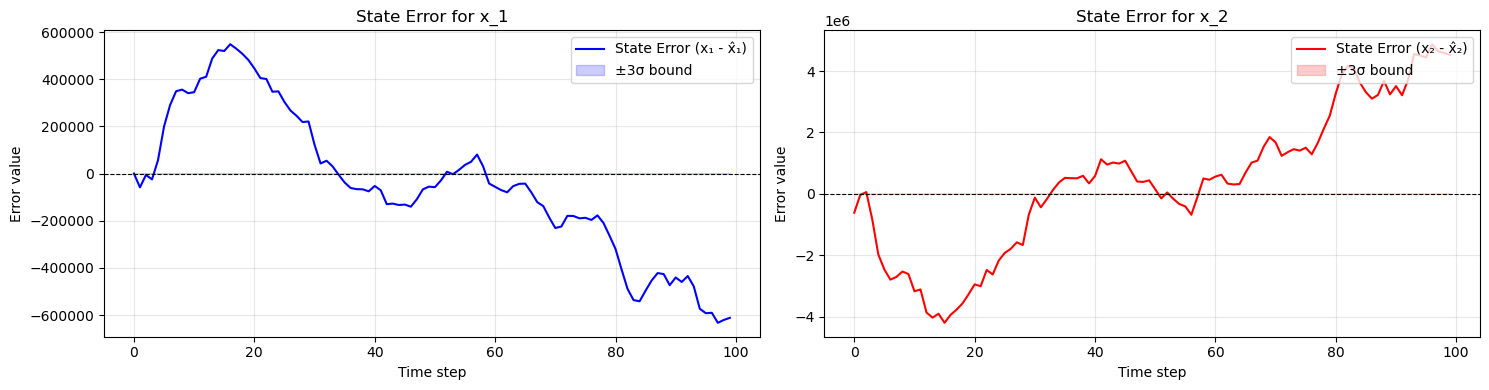

Percentage of x_1 errors within ±3σ bounds: 1.0%
Percentage of x_2 errors within ±3σ bounds: 0.0%


In [8]:
# State error with bounds
xerrJKF = xk -  xhatstore_joseph

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
axs[0].plot(time_idx, xerrJKF[:, 0], label='State Error (x₁ - x̂₁)', color='blue')
axs[0].fill_between(time_idx,
                    -boundstore_joseph[:, 0],
                    boundstore_joseph[:, 0],
                    color='blue', alpha=0.2, label='±3σ bound')
axs[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[0].set_xlabel('Time step')
axs[0].set_ylabel('Error value')
axs[0].set_title('State Error for x_1')
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

axs[1].plot(time_idx, xerrJKF[:, 1], label='State Error (x₂ - x̂₂)', color='red')
axs[1].fill_between(time_idx,
                    -boundstore_joseph[:, 1],
                    boundstore_joseph[:, 1],
                    color='red', alpha=0.2, label='±3σ bound')
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8)
axs[1].set_xlabel('Time step')
axs[1].set_ylabel('Error value')
axs[1].set_title('State Error for x_2')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate percentage of errors within bounds
within_bounds_x1 = np.sum(np.abs(xerrJKF[:, 0]) <= boundstore_joseph[:, 0]) / size * 100
within_bounds_x2 = np.sum(np.abs(xerrJKF[:, 1]) <= boundstore_joseph[:, 1]) / size * 100
print(f"Percentage of x_1 errors within ±3σ bounds: {within_bounds_x1:.1f}%")
print(f"Percentage of x_2 errors within ±3σ bounds: {within_bounds_x2:.1f}%")

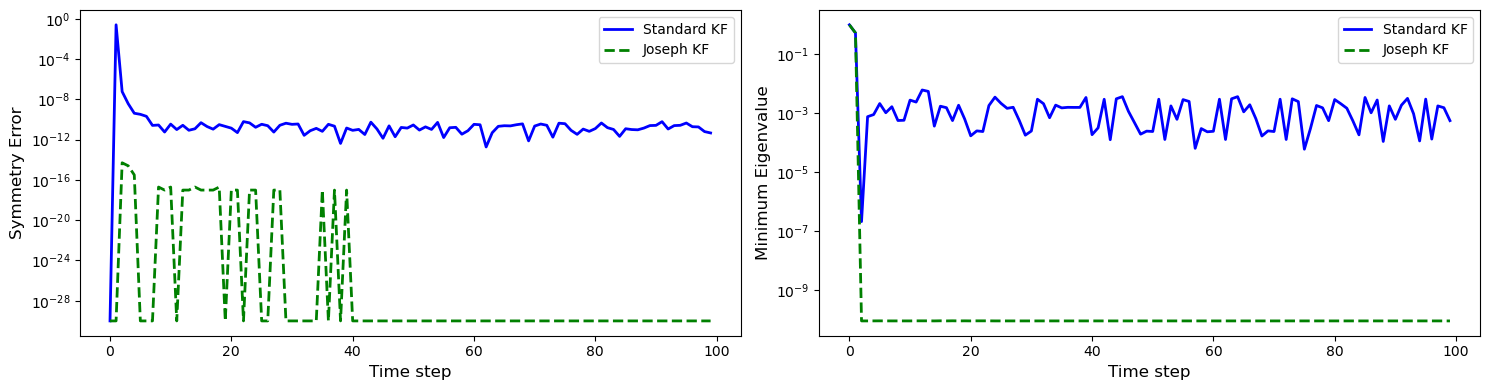

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(15, 4))

#Symmetry error (log scale)
axs[0].plot(time_idx, symmetry_error_std + 1e-30, label='Standard KF', color='blue', linewidth=2)
axs[0].plot(time_idx, symmetry_error_joseph + 1e-30, label='Joseph KF', color='green', linestyle='--', linewidth=2)
axs[0].set_yscale('log')
# axs[0].set_ylim(ymin=1e-30, ymax=1e-9)
axs[0].set_xlabel('Time step', fontsize=12)
axs[0].set_ylabel('Symmetry Error', fontsize=12)
axs[0].legend(loc='best')
# axs[0].grid(True, alpha=0.3, which='both')

#Minimum eigenvalues (log scale)
axs[1].plot(time_idx, np.abs(min_eigenvalues_std), label='Standard KF', color='blue', linewidth=2)
axs[1].plot(time_idx, np.abs(min_eigenvalues_joseph), label='Joseph KF', color='green', linestyle='--', linewidth=2)
# axs[1].axhline(y=1e-16, color='red', linestyle=':', linewidth=1, label='Reference (≈0)')
axs[1].set_yscale('log')
axs[1].set_xlabel('Time step', fontsize=12)
axs[1].set_ylabel('Minimum Eigenvalue', fontsize=12)
axs[1].legend(loc='best')
# axs[1].grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

3. condition number

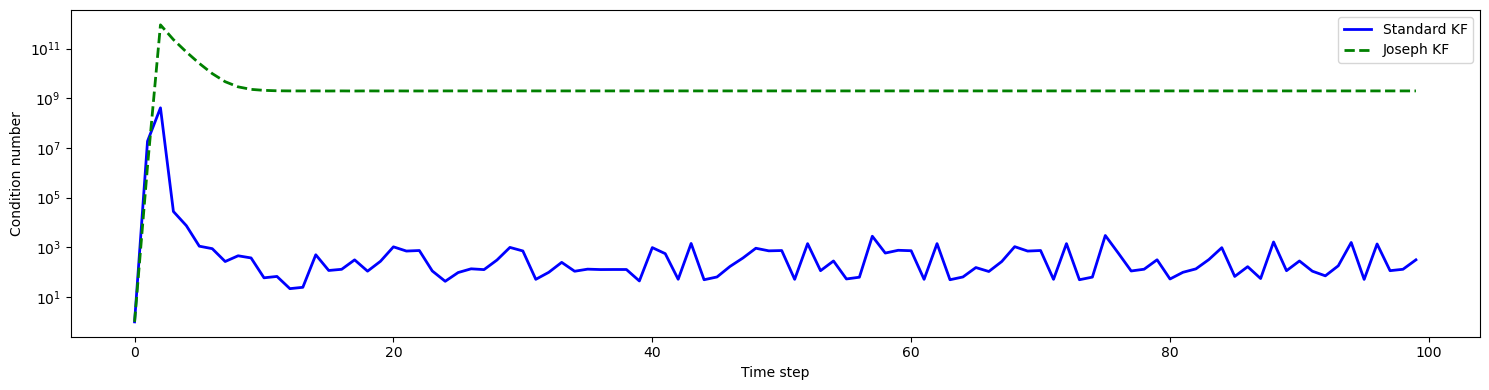

In [11]:
# Condition number vs time step 
cn_std = np.asarray(condition_number_std, dtype=float)
cn_jkf = np.asarray(condition_number_joseph, dtype=float)

plt.figure(figsize=(15, 4))
plt.plot(time_idx, cn_std, label='Standard KF', color='blue', linewidth=2)
plt.plot(time_idx, cn_jkf, label='Joseph KF', color='green', linestyle='--', linewidth=2)
# plt.axhline(1.0, color='gray', linestyle=':', linewidth=1, label='Ideal (κ=1)')
plt.xlabel('Time step')
plt.ylabel('Condition number')
plt.yscale('log')
plt.legend(loc='best')
# plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

END